In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
csv_path=Path(r"C:\Users\ASUS\OneDrive\Desktop\data scicne fayllar\cleanned.csv")
df=pd.read_csv(csv_path)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,41,Female,typical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0
...,...,...,...,...,...,...,...,...,...,...,...
913,54,Female,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,1
914,62,Male,typical angina,130.0,139.0,False,st-t abnormality,140.0,False,0.5,0
915,55,Male,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,2
916,58,Male,asymptomatic,130.0,385.0,True,lv hypertrophy,140.0,False,0.5,0


In [3]:
df['num'].value_counts()

num
0    410
1    265
2    108
3    107
4     28
Name: count, dtype: int64

In [4]:
df['num'].value_counts()[0]

np.int64(410)

In [5]:
df['num'].value_counts()[1:4].sum()

np.int64(480)

In [6]:
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    object 
 2   cp        918 non-null    object 
 3   trestbps  918 non-null    float64
 4   chol      918 non-null    float64
 5   fbs       918 non-null    bool   
 6   restecg   918 non-null    object 
 7   thalch    918 non-null    float64
 8   exang     918 non-null    bool   
 9   oldpeak   918 non-null    float64
 10  num       918 non-null    int64  
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 66.5+ KB


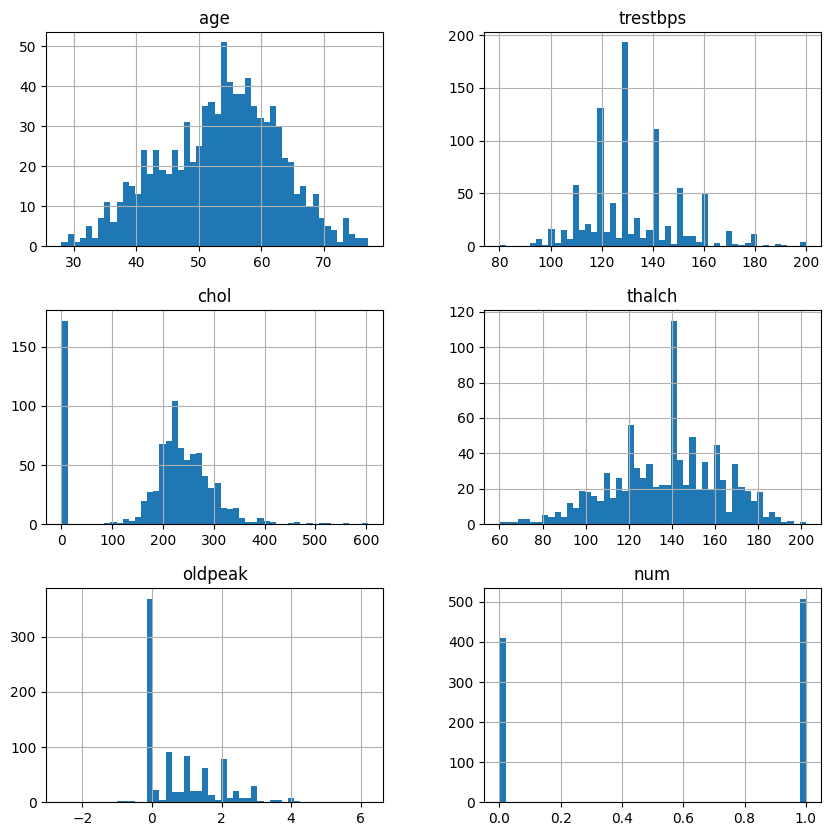

In [8]:
df.hist(bins=50,figsize=(10,10))
plt.show()

In [9]:
df["chol"] = df["chol"].replace(0, np.nan)
df["chol"].fillna(df["chol"].median(), inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16652\3364558674.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["chol"].fillna(df["chol"].median(), inplace=True)


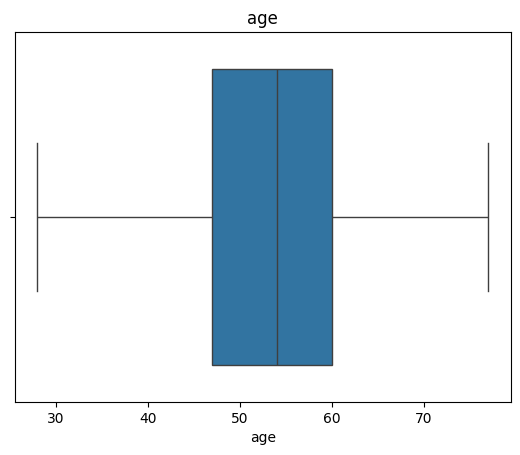

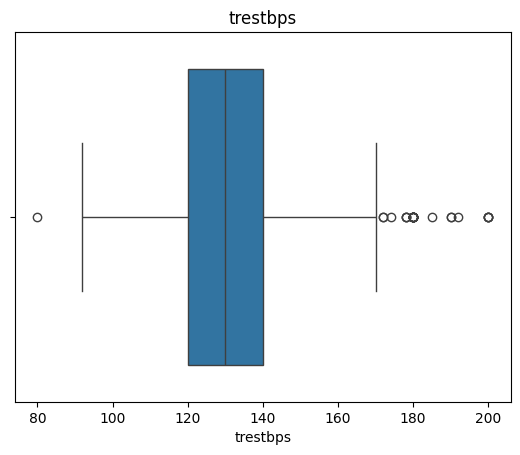

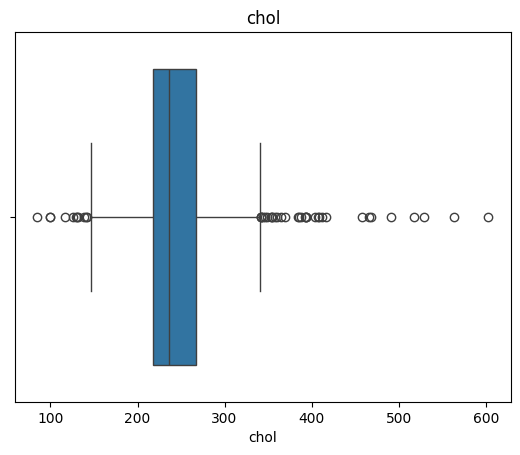

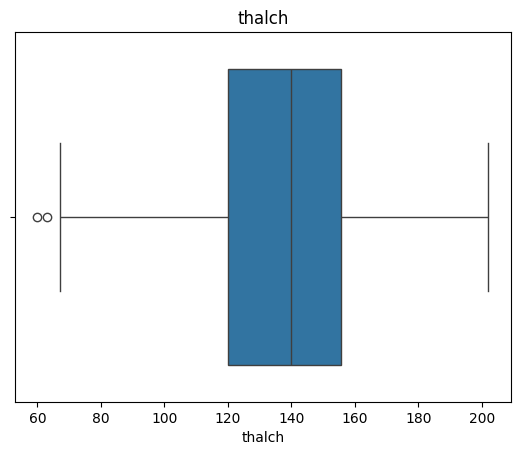

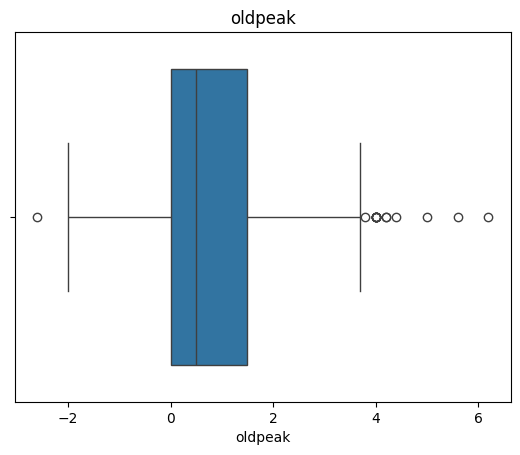

In [10]:
import seaborn as sns

for col in ["age","trestbps","chol","thalch","oldpeak"]:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [11]:
cols = ["age","trestbps","chol","thalch","oldpeak"]

for col in cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(col, "outlier sayı:", outliers.shape[0])

age outlier sayı: 0
trestbps outlier sayı: 27
chol outlier sayı: 44
thalch outlier sayı: 2
oldpeak outlier sayı: 16


In [12]:
cols = ["age","trestbps","chol","thalch","oldpeak"]

for col in cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Yeni dataset ölçüsü:", df.shape)

Yeni dataset ölçüsü: (829, 11)


In [13]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,41,Female,typical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0
...,...,...,...,...,...,...,...,...,...,...,...
911,62,Male,asymptomatic,158.0,170.0,False,st-t abnormality,138.0,True,0.0,1
912,46,Male,asymptomatic,134.0,310.0,False,normal,126.0,False,0.0,1
913,54,Female,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,1
915,55,Male,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,1


In [14]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix['num'].sort_values()

thalch     -0.381400
trestbps    0.094568
chol        0.097614
fbs         0.112698
age         0.299994
oldpeak     0.366354
exang       0.420998
num         1.000000
Name: num, dtype: float64

In [15]:
import plotly.express as px

fig = px.imshow(
    corr_matrix, 
    color_continuous_scale='RdBu', 
    text_auto=".2f",
	aspect='auto'
)
fig.update_layout(margin={
		't':0, 
		'b':0, 
	},
	width=400
)  

In [16]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,41,Female,typical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 829 entries, 0 to 917
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       829 non-null    int64  
 1   sex       829 non-null    object 
 2   cp        829 non-null    object 
 3   trestbps  829 non-null    float64
 4   chol      829 non-null    float64
 5   fbs       829 non-null    bool   
 6   restecg   829 non-null    object 
 7   thalch    829 non-null    float64
 8   exang     829 non-null    bool   
 9   oldpeak   829 non-null    float64
 10  num       829 non-null    int64  
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 66.4+ KB


In [18]:
X = df.drop('num', axis='columns')
y = df['num']

In [19]:
X.select_dtypes(include=["float64","int64"]).columns
X.select_dtypes(include=["object","bool"]).columns

Index(['sex', 'cp', 'fbs', 'restecg', 'exang'], dtype='object')

In [20]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder,FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor

num_cols=['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
cat_cols=['sex', 'cp', 'fbs', 'restecg', 'exang']

num_pipeline=Pipeline([
    ("imp",SimpleImputer(strategy='median')),
    ("scl", StandardScaler())
])
cat_pipeline=Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('scl', OneHotEncoder(sparse_output=False,handle_unknown='ignore')) 
])

preprocessing=ColumnTransformer([
    ("Num",num_pipeline,num_cols),
    ("cat",cat_pipeline,cat_cols),
])
X_arr = preprocessing.fit_transform(X)
X_tr = pd.DataFrame(X_arr, columns=preprocessing.get_feature_names_out())
X_tr


,Num__age,Num__trestbps,Num__chol,Num__thalch,Num__oldpeak,cat__sex_Female,cat__sex_Male,cat__cp_asymptomatic,cat__cp_non-anginal,cat__cp_typical angina,cat__fbs_False,cat__fbs_True,cat__restecg_lv hypertrophy,cat__restecg_normal,cat__restecg_st-t abnormality,cat__exang_False,cat__exang_True
0,1.006740,0.927037,-0.144105,0.483609,1.568455,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,1.426923,1.883852,1.275208,-1.204442,0.735896,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.426923,-0.667654,-0.251223,-0.360416,1.880665,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.724446,-0.029778,0.311146,1.970703,2.817294,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-1.304264,-0.029778,-0.920710,1.367827,0.631826,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
824,0.901695,1.756276,-1.831213,0.001309,-0.825152,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
825,-0.779036,0.225373,1.917915,-0.480991,-0.825152,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
826,0.061329,-0.221141,2.533844,0.644376,-0.825152,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
827,0.166375,-0.540079,-0.411900,-1.525976,-0.825152,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0


In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2
    )

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
full_pipeline = Pipeline([
	("cleaning", preprocessing),
	("model", LogisticRegression())
])

full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)
y_pred

array([0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1])

In [24]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.7951807228915663

In [25]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
f1

0.8172043010752689

In [26]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred)
recall

0.9047619047619048